<a href="https://colab.research.google.com/github/boemer00/courses/blob/main/Template_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:
import os
import math
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint as sp_randint


In [93]:
class DataLoader:
    def __init__(self, url, missing_values, random_seed=None):
        self.url = url
        self.missing_values = missing_values
        self.random_seed = random_seed

    def load_data(self):
        df = pd.read_csv(self.url, na_values=self.missing_values)
        if self.random_seed is not None:
            df = df.sample(frac=1, random_state=self.random_seed)
        return df

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
missing_values = ['na', '?', ' ', '', 'N/A', 'n/a']

data_loader = DataLoader(url, missing_values, random_seed=42)
df = data_loader.load_data()

## Data Cleaning & EDA

In [94]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 891 entries, 709 to 102
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.5+ KB


In [96]:
df.shape[0] - df.drop_duplicates(subset='PassengerId').shape[0]

0

In [97]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [98]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.00,257.35,1.00,223.50,446.00,668.5,891.00
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


In [57]:
# sns.scatterplot(x='Age', y='Survived', data=df, hue='Survived', alpha=0.5);
# sns.barplot(x='Pclass', y='Survived', data=df);
# corr = df.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', vmax=1, vmin=-1)

In [99]:
for col in df.columns:
  print(f'{col}:, {df[col].nunique()}')


PassengerId:, 891
Survived:, 2
Pclass:, 3
Name:, 891
Sex:, 2
Age:, 88
SibSp:, 7
Parch:, 7
Ticket:, 681
Fare:, 248
Cabin:, 147
Embarked:, 3


### Age

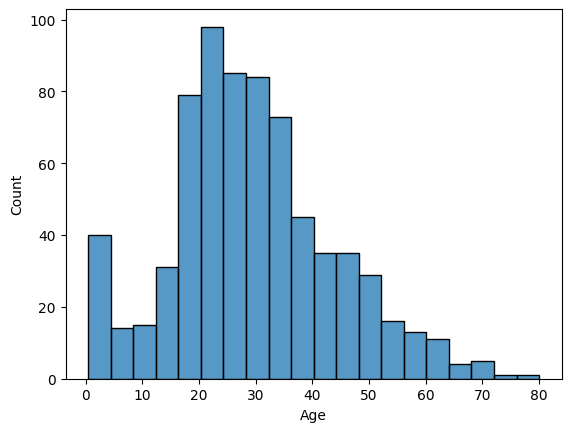

In [100]:
sns.histplot(df['Age']);

### Embarked

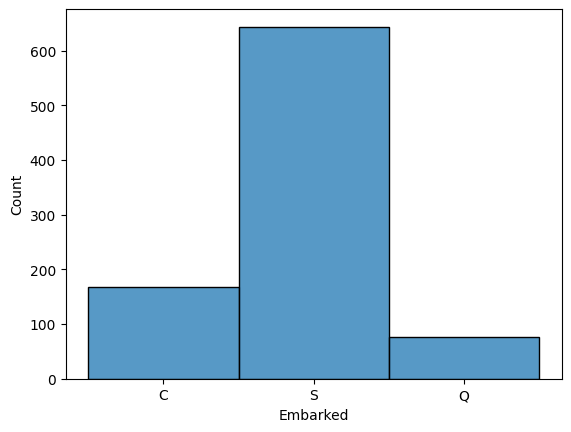

In [101]:
sns.histplot(df['Embarked']);

In [102]:
class DataCleaning:
  def __init__(self, df):
    self.df = df

  def drop_duplicates(self):
    self.df.drop_duplicates(subset='PassengerId', inplace=True)

  def drop_unnecessary_col(self):
    self.df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True, errors='ignore')

  def transform_age(self):
    age_median = self.df['Age'].median()
    self.df['Age'].fillna(age_median, inplace=True)

  def transform_sex(self):
    self.df['Sex'] = self.df['Sex'].map({'female': 0, 'male': 1})

  def transform_embarked(self):
    embarked_mode = self.df['Embarked'].mode()[0]
    self.df['Embarked'].fillna(embarked_mode, inplace=True)
    self.df['Embarked'] = self.df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

  def clean_data(self):
        self.drop_duplicates()
        self.drop_unnecessary_col()
        self.transform_age()
        self.transform_sex()
        self.transform_embarked()

In [103]:
cleaner = DataCleaning(df)
cleaner.clean_data()

df = cleaner.df

In [105]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,1,3,1,28.0,1,1,15.2458,1
439,0,2,1,31.0,0,0,10.5000,0
840,0,3,1,20.0,0,0,7.9250,0
720,1,2,0,6.0,0,1,33.0000,0
39,1,3,0,14.0,1,0,11.2417,1


## Model

In [122]:
X = df.drop(columns=['Survived'])
y = df['Survived']

def cross_validation_score(X, y, n_estimators=100, cv=5):
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv)
    print(f'Averag cv score: {np.mean(cv_scores):.4f}')

cross_validation_score(X, y, n_estimators=100, cv=5)

Averag cv score: 0.8126


In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [124]:
params = {
    'n_estimators': sp_randint(100, 1000),
    'max_depth': sp_randint(3, 20),
    'min_samples_split': sp_randint(2, 11),
    'min_samples_leaf': sp_randint(1, 11),
    'max_features': ['auto', 'sqrt', 'log2']
}

# Create a RandomForestClassifier
model = RandomForestClassifier()

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(model, param_distributions=params, n_iter=100, cv=5, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 476}
Best Score: 0.839850290554516


In [134]:
class ModelTraining:
    def __init__(self):
        best_params = {
            'max_depth': 9,
            'max_features': 'sqrt',
            'min_samples_leaf': 1,
            'min_samples_split': 2,
            'n_estimators': 476
        }
        self.model = RandomForestClassifier(**best_params)

    def train(self, X, y):
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)

    def save_model(self, file_path):
        joblib.dump(self.model, file_path)


In [135]:
# Create an instance of the class and train the model
model_trainer = ModelTraining()
model_trainer.train(X_train, y_train)

# Save the model
model_trainer.save_model('random_forest_model.pkl')


## Pipeline

In [142]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

In [141]:
class DataCleaning(BaseEstimator, TransformerMixin):
    def __init__(self, age_index, embarked_index, sex_index, columns_to_drop_indices):
        self.age_index = age_index
        self.embarked_index = embarked_index
        self.sex_index = sex_index
        self.columns_to_drop_indices = columns_to_drop_indices

    def fit(self, X, y=None):
        # Compute and store the median and mode based on column indices
        self.age_median = np.nanmedian(X[:, self.age_index])
        self.embarked_mode = np.bincount(X[:, self.embarked_index].astype(int)).argmax()
        return self

    def transform(self, X, y=None):
        # Fill missing values in 'Age'
        X[:, self.age_index] = np.where(np.isnan(X[:, self.age_index]), self.age_median, X[:, self.age_index])

        # Transform 'Sex' column
        X[:, self.sex_index] = np.where(X[:, self.sex_index] == 'female', 0, 1)

        # Transform 'Embarked'
        X[:, self.embarked_index] = np.where(np.isnan(X[:, self.embarked_index]), self.embarked_mode, X[:, self.embarked_index])

        # Drop unnecessary columns
        X = np.delete(X, self.columns_to_drop_indices, axis=1)

        return X


In [137]:
# for i, col in enumerate(df_original.columns):
#     print(f'{i} {col}')

In [143]:
# Define column indices for cleaning
age_index = 5
embarked_index = 11
sex_index = 4
columns_to_drop_indices = [0, 3, 8, 10]

# Initialise the cleaner
data_cleaner = DataCleaning(age_index, embarked_index, sex_index, columns_to_drop_indices)

# Build the pipeline
pipeline = Pipeline([
    ('cleaner', data_cleaner),

])


In [144]:
# Save the pipeline
joblib.dump(pipeline, 'pipeline.pkl')


['pipeline.pkl']

## Predict

In [145]:
import joblib
from sklearn.metrics import accuracy_score

# Load and predict
trained_model = joblib.load('random_forest_model.pkl')

predictions = trained_model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7821
